<a href="https://colab.research.google.com/github/poonam-021/explainable-ai-stress-burnout/blob/main/models/notebook227331bf70.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
dartweichen_student_life_path = kagglehub.dataset_download('dartweichen/student-life')

print('Data source import complete.')


In [ ]:
import os

print(os.listdir('/kaggle/input'))

['datasets']


In [ ]:
import os
print(os.listdir('/kaggle/input/datasets'))

['dartweichen']


In [ ]:
import os
print(os.listdir('/kaggle/input/datasets/dartweichen'))

['student-life']


In [ ]:
import os
print(os.listdir('/kaggle/input/datasets/dartweichen/student-life'))

['dataset']


In [ ]:
import os
print(os.listdir('/kaggle/input/datasets/dartweichen/student-life/dataset'))

['EMA', 'app_usage', 'sensing', 'calendar', 'call_log', 'education', 'survey', 'dinning', 'sms']


In [ ]:
print(os.listdir('/kaggle/input/datasets/dartweichen/student-life/dataset/EMA'))

['response', 'EMA_definition.json']


In [ ]:
import os
print(os.listdir('/kaggle/input/datasets/dartweichen/student-life/dataset/EMA/response'))

['Stress', 'Exercise', 'QR_Code', 'Green Key 2', 'Class', 'PAM', 'Behavior', 'Mood 2', 'Dartmouth now', 'Study Spaces', 'Mood 1', 'Cancelled Classes', 'Class 2', 'Events', 'Boston Bombing', 'Dining Halls', 'Green Key 1', 'Administration response', 'Social', 'Lab', 'Dimensions', 'Sleep', 'Mood', 'Dimensions protestors', 'Activity', 'Comment']


In [ ]:
print(os.listdir('/kaggle/input/datasets/dartweichen/student-life/dataset/EMA/response/Stress'))

['Stress_u31.json', 'Stress_u36.json', 'Stress_u20.json', 'Stress_u22.json', 'Stress_u07.json', 'Stress_u05.json', 'Stress_u51.json', 'Stress_u27.json', 'Stress_u56.json', 'Stress_u23.json', 'Stress_u09.json', 'Stress_u54.json', 'Stress_u15.json', 'Stress_u34.json', 'Stress_u42.json', 'Stress_u30.json', 'Stress_u02.json', 'Stress_u16.json', 'Stress_u46.json', 'Stress_u58.json', 'Stress_u44.json', 'Stress_u47.json', 'Stress_u03.json', 'Stress_u19.json', 'Stress_u00.json', 'Stress_u32.json', 'Stress_u01.json', 'Stress_u49.json', 'Stress_u12.json', 'Stress_u24.json', 'Stress_u50.json', 'Stress_u17.json', 'Stress_u33.json', 'Stress_u45.json', 'Stress_u25.json', 'Stress_u08.json', 'Stress_u53.json', 'Stress_u43.json', 'Stress_u52.json', 'Stress_u57.json', 'Stress_u10.json', 'Stress_u39.json', 'Stress_u14.json', 'Stress_u59.json', 'Stress_u13.json', 'Stress_u18.json', 'Stress_u04.json', 'Stress_u41.json', 'Stress_u35.json']


In [ ]:
import os
import json
import pandas as pd

base_path = '/kaggle/input/datasets/dartweichen/student-life/dataset/EMA/response/Stress'

all_data = []

for file in os.listdir(base_path):
    if file.endswith('.json'):
        user = file.split('_')[1].split('.')[0]  # extract user id

        with open(os.path.join(base_path, file)) as f:
            data = json.load(f)

            # data is already a list
            df = pd.json_normalize(data)
            df['user'] = user

            all_data.append(df)

stress_df = pd.concat(all_data, ignore_index=True)

stress_df.head()

,null,resp_time,level,location,user
0,3,1364122031,NaN,NaN,u31
1,"43.70591546,-72.28812724",1364122034,NaN,NaN,u31
2,"43.70450657,-72.28874981",1364122032,NaN,NaN,u31
3,2,1364122036,NaN,NaN,u31
4,"43.70628474,-72.2870415",1364118589,NaN,NaN,u31


In [ ]:
# Combine level and null columns
stress_df['stress_raw'] = stress_df['level'].fillna(stress_df['null'])

# Remove rows where stress_raw is not numeric
stress_df = stress_df[pd.to_numeric(stress_df['stress_raw'], errors='coerce').notnull()]

# Convert to integer
stress_df['stress'] = stress_df['stress_raw'].astype(int)

stress_df[['stress','resp_time','user']].head()

,stress,resp_time,user
0,3,1364122031,u31
3,2,1364122036,u31
5,4,1364508024,u31
6,5,1364594440,u31
7,3,1364684254,u31


In [ ]:
# Convert UNIX timestamp to datetime
stress_df['datetime'] = pd.to_datetime(stress_df['resp_time'], unit='s')

# Extract date
stress_df['date'] = stress_df['datetime'].dt.date

stress_df[['user','stress','datetime','date']].head()

,user,stress,datetime,date
0,u31,3,2013-03-24 10:47:11,2013-03-24
3,u31,2,2013-03-24 10:47:16,2013-03-24
5,u31,4,2013-03-28 22:00:24,2013-03-28
6,u31,5,2013-03-29 22:00:40,2013-03-29
7,u31,3,2013-03-30 22:57:34,2013-03-30


In [ ]:
daily_stress = (
    stress_df
    .groupby(['user', 'date'])['stress']
    .mean()
    .reset_index()
)

daily_stress.head()

,user,date,stress
0,u00,2013-03-25,1.333333
1,u00,2013-03-26,2.000000
2,u00,2013-03-27,1.000000
3,u00,2013-03-28,2.666667
4,u00,2013-03-29,2.500000


In [ ]:
len(daily_stress)

1289

In [ ]:
daily_stress['user'].nunique()

49

In [ ]:
daily_stress['stress'].describe()

count    1289.000000
mean        2.255227
std         1.209557
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         5.000000
Name: stress, dtype: float64

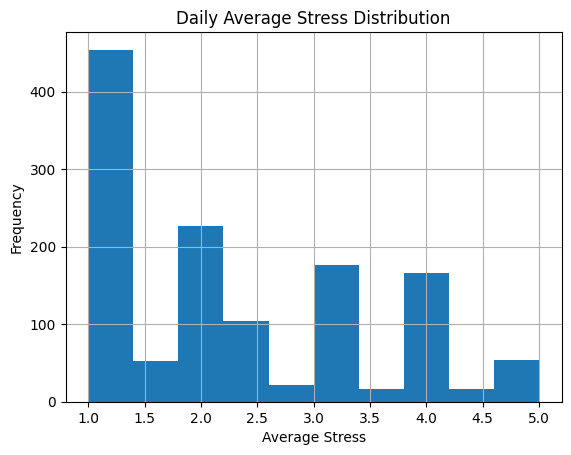

In [ ]:
import matplotlib.pyplot as plt

daily_stress['stress'].hist()
plt.title("Daily Average Stress Distribution")
plt.xlabel("Average Stress")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print(os.listdir('/kaggle/input/datasets/dartweichen/student-life/dataset/app_usage'))

['running_app_u32.csv', 'running_app_u04.csv', 'running_app_u25.csv', 'running_app_u34.csv', 'running_app_u56.csv', 'running_app_u54.csv', 'running_app_u15.csv', 'running_app_u39.csv', 'running_app_u07.csv', 'running_app_u05.csv', 'running_app_u42.csv', 'running_app_u30.csv', 'running_app_u53.csv', 'running_app_u16.csv', 'running_app_u58.csv', 'running_app_u24.csv', 'running_app_u02.csv', 'running_app_u00.csv', 'running_app_u59.csv', 'running_app_u33.csv', 'running_app_u10.csv', 'running_app_u08.csv', 'running_app_u57.csv', 'running_app_u44.csv', 'running_app_u47.csv', 'running_app_u27.csv', 'running_app_u41.csv', 'running_app_u50.csv', 'running_app_u36.csv', 'running_app_u18.csv', 'running_app_u43.csv', 'running_app_u12.csv', 'running_app_u46.csv', 'running_app_u14.csv', 'running_app_u20.csv', 'running_app_u45.csv', 'running_app_u01.csv', 'running_app_u35.csv', 'running_app_u13.csv', 'running_app_u31.csv', 'running_app_u51.csv', 'running_app_u22.csv', 'running_app_u09.csv', 'running_a

In [ ]:
import pandas as pd
import os

app_path = '/kaggle/input/datasets/dartweichen/student-life/dataset/app_usage'

app_data = []

for file in os.listdir(app_path):
    if file.endswith('.csv'):
        user = file.split('_')[2].split('.')[0]  # extract user id

        df = pd.read_csv(os.path.join(app_path, file))
        df['user'] = user

        app_data.append(df)

app_df = pd.concat(app_data, ignore_index=True)

app_df.head()

,id,device,timestamp,RUNNING_TASKS_baseActivity_mClass,RUNNING_TASKS_baseActivity_mPackage,RUNNING_TASKS_id,RUNNING_TASKS_numActivities,RUNNING_TASKS_numRunning,RUNNING_TASKS_topActivity_mClass,RUNNING_TASKS_topActivity_mPackage,user
0,3d37b566-af7a-4d6d-ad8f-6465bea39265-123,dabe32a5-8e08-44d2-8617-81b0b46bf92e,1364106626,com.google.android.apps.paco.ExperimentManager...,com.google.android.apps.paco,11,1,1,com.google.android.apps.paco.ExperimentManager...,com.google.android.apps.paco,u32
1,3d37b566-af7a-4d6d-ad8f-6465bea39265-123,dabe32a5-8e08-44d2-8617-81b0b46bf92e,1364106626,com.android.launcher2.Launcher,com.android.launcher,2,1,1,com.android.launcher2.Launcher,com.android.launcher,u32
2,3d37b566-af7a-4d6d-ad8f-6465bea39265-123,dabe32a5-8e08-44d2-8617-81b0b46bf92e,1364106626,org.bewellapp.dashBoardActivity,org.bewellapp,6,1,1,org.bewellapp.dashBoardActivity,org.bewellapp,u32
3,2620c2bc-0433-4369-966c-ba8d218995e7-549,dabe32a5-8e08-44d2-8617-81b0b46bf92e,1364105426,com.android.launcher2.Launcher,com.android.launcher,2,1,1,com.android.launcher2.Launcher,com.android.launcher,u32
4,2620c2bc-0433-4369-966c-ba8d218995e7-549,dabe32a5-8e08-44d2-8617-81b0b46bf92e,1364105426,org.bewellapp.dashBoardActivity,org.bewellapp,6,1,1,org.bewellapp.dashBoardActivity,org.bewellapp,u32


In [ ]:
# Keep only required columns
app_df = app_df[['user', 'timestamp', 'RUNNING_TASKS_topActivity_mPackage']]

# Rename for simplicity
app_df.rename(columns={
    'RUNNING_TASKS_topActivity_mPackage': 'app'
}, inplace=True)

app_df.head()

,user,timestamp,app
0,u32,1364106626,com.google.android.apps.paco
1,u32,1364106626,com.android.launcher
2,u32,1364106626,org.bewellapp
3,u32,1364105426,com.android.launcher
4,u32,1364105426,org.bewellapp


In [ ]:
app_df['datetime'] = pd.to_datetime(app_df['timestamp'], unit='s')
app_df['date'] = app_df['datetime'].dt.date

app_df.head()

,user,timestamp,app,datetime,date
0,u32,1364106626,com.google.android.apps.paco,2013-03-24 06:30:26,2013-03-24
1,u32,1364106626,com.android.launcher,2013-03-24 06:30:26,2013-03-24
2,u32,1364106626,org.bewellapp,2013-03-24 06:30:26,2013-03-24
3,u32,1364105426,com.android.launcher,2013-03-24 06:10:26,2013-03-24
4,u32,1364105426,org.bewellapp,2013-03-24 06:10:26,2013-03-24


In [ ]:
daily_app = (
    app_df
    .groupby(['user', 'date'])
    .agg(
        total_app_events=('app', 'count'),
        unique_apps=('app', 'nunique')
    )
    .reset_index()
)

daily_app.head()

,user,date,total_app_events,unique_apps
0,u00,2013-03-24,472,22
1,u00,2013-03-25,630,21
2,u00,2013-03-26,737,12
3,u00,2013-03-27,780,19
4,u00,2013-03-28,865,25


In [ ]:
len(daily_app)

3083

In [ ]:
daily_app.describe()

,total_app_events,unique_apps
count,3083.00000,3083.000000
mean,645.64061,12.421992
std,556.58455,7.906084
min,1.00000,1.000000
25%,263.00000,7.000000
50%,498.00000,11.000000
75%,868.50000,17.000000
max,4136.00000,58.000000


In [ ]:
merged_df = pd.merge(daily_stress, daily_app, on=['user','date'], how='inner')

merged_df.head()

,user,date,stress,total_app_events,unique_apps
0,u00,2013-03-25,1.333333,630,21
1,u00,2013-03-26,2.000000,737,12
2,u00,2013-03-27,1.000000,780,19
3,u00,2013-03-28,2.666667,865,25
4,u00,2013-03-29,2.500000,705,16


In [ ]:
len(merged_df)

1263

In [ ]:
merged_df.describe()

,stress,total_app_events,unique_apps
count,1263.000000,1263.000000,1263.000000
mean,2.250188,769.904196,14.331750
std,1.210031,607.656091,8.248325
min,1.000000,22.000000,2.000000
25%,1.000000,331.500000,8.000000
50%,2.000000,618.000000,13.000000
75%,3.000000,1034.000000,19.000000
max,5.000000,4136.000000,58.000000


In [ ]:
merged_df[['stress','total_app_events','unique_apps']].corr()

,stress,total_app_events,unique_apps
stress,1.000000,0.029711,0.042363
total_app_events,0.029711,1.000000,0.884650
unique_apps,0.042363,0.884650,1.000000


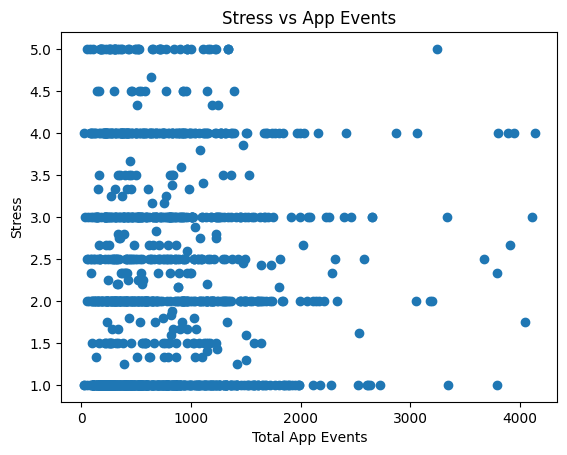

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(merged_df['total_app_events'], merged_df['stress'])
plt.xlabel("Total App Events")
plt.ylabel("Stress")
plt.title("Stress vs App Events")
plt.show()

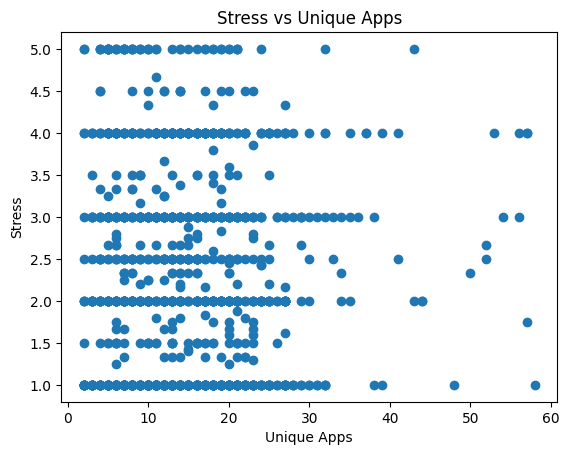

In [ ]:
plt.scatter(merged_df['unique_apps'], merged_df['stress'])
plt.xlabel("Unique Apps")
plt.ylabel("Stress")
plt.title("Stress vs Unique Apps")
plt.show()

In [ ]:
merged_df.isnull().sum()

user                0
date                0
stress              0
total_app_events    0
unique_apps         0
dtype: int64